In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv('/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv',encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [3]:
df = df.head(70000)
df = df[['comment', 'label']]
df = df.dropna()

In [4]:
!pip install hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.6/892.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 97.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 100.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.7 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9297 sha256=c978307b0ea24a590bc1b451f855de68fbe004bfbec9c5446d32efa3def96f44
  Stored in directory: /root/.cache/pip/wheels/bc/be/39/c37ad168eb2ff644c9685f52554440372129450f0b8ed203dd
Successfully built flashtext
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
     

In [5]:
from hazm import Normalizer

# نرمال‌سازی متن‌ها
normalizer = Normalizer()

def preprocess_text(text):
    # حذف فاصله‌های اضافی، تبدیل اعداد انگلیسی به فارسی، و نرمال‌سازی متن
    return normalizer.normalize(text)

# اعمال پیش‌پردازش روی ستون 'comment'
df['comment'] = df['comment'].apply(preprocess_text)

# بررسی نتیجه
print(df.head())

# ذخیره دیتاست پیش‌پردازش شده
# data.to_csv("Snappfood-Sentiment Analysis_preprocessed.csv", index=False)
# print("پیش‌پردازش انجام شد و دیتاست ذخیره گردید.")

                                             comment  label
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح    SAD
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...  HAPPY
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...    SAD
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...  HAPPY
4                      شیرینی وانیلی فقط یک مدل بود.  HAPPY


In [6]:
def load_data(file_path, stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python'):
    df = pd.read_csv(file_path, encoding=encoding, sep=sep, on_bad_lines=on_bad_lines, engine=engine)
    # ادامه پردازش داده‌ها...
    return df


In [7]:
# مثال کلمات توقف
stop_words = ["و", "به", "از", "که", "در", "چرا", "هم", "چه", "یا", "با", "تا", "نیز", "را", "پس", "چون", "ولی", "چه", "اگر", "اما", "زیرا", "بس", "ازبس"]

file_path = '/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv'  # مسیر جدید داده‌ها
data = load_data(file_path, stop_words=stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [8]:
def preprocess_data(data, stop_words):
    def remove_stop_words(comment):
        return ' '.join([word for word in text.split() if word not in stop_words])

    data['comment'] = data['comment'].apply(remove_stop_words)
    return data


In [9]:
def map_labels(label):
    if label == "HAPPY":
        return 1
    else:
        return 0

df['label'] = df['label'].apply(map_labels)

In [10]:
print(df['label'].value_counts())

label
0    35000
1    35000
Name: count, dtype: int64


In [11]:
df['comment_length'] = df['comment'].apply(len)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


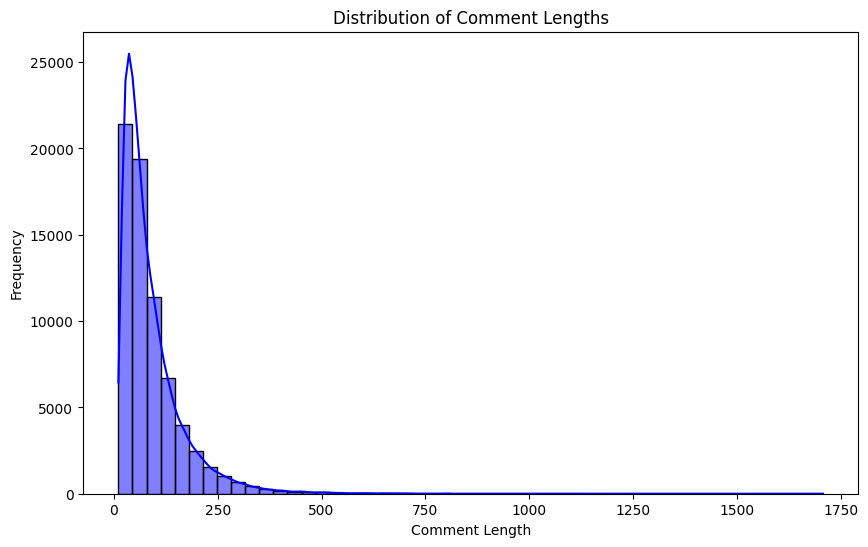

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

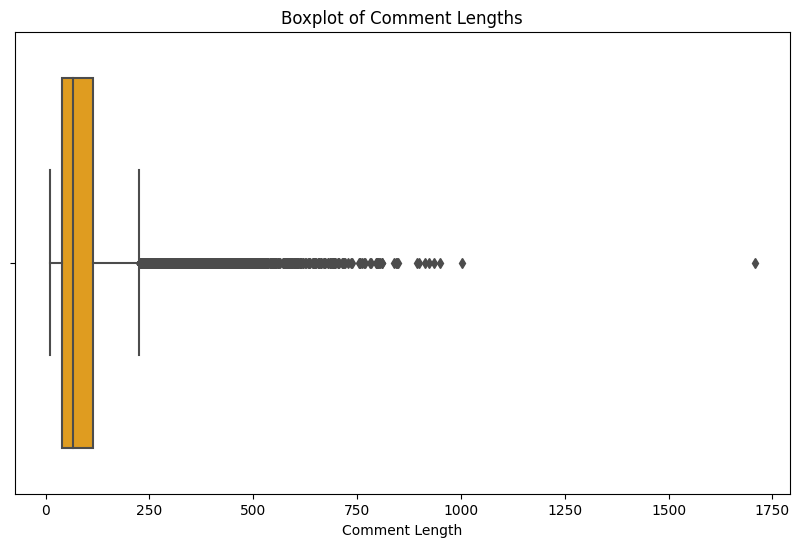

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()

In [14]:
# محاسبه چارک‌ها  IQR

Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# تعیین حدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# حذف داده‌های پرت
cleaned_df = df[(df['comment_length'] >= lower_bound) & (df['comment_length'] <= upper_bound)]
print(f"تعداد داده‌های باقی‌مانده: {cleaned_df.shape[0]}")

Upper limit: -73.5
Lower limit: 226.5
تعداد داده‌های باقی‌مانده: 66024


In [15]:
# شمارش داده‌هایی که طول متن آن‌ها بیشتر از 226 است
greater_than_226 = cleaned_df[cleaned_df['comment_length'] > 226].shape[0]

# شمارش داده‌هایی که طول متن آن‌ها بین 0 تا 226 است
between_0_and_226 = cleaned_df[(cleaned_df['comment_length'] > 0) & (cleaned_df['comment_length'] <= 226)].shape[0]

print(f"تعداد داده‌هایی که طول متن آن‌ها بیشتر از 226 است: {greater_than_226}")
print(f"تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 226 است: {between_0_and_226}")

تعداد داده‌هایی که طول متن آن‌ها بیشتر از 226 است: 0
تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 226 است: 66024


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


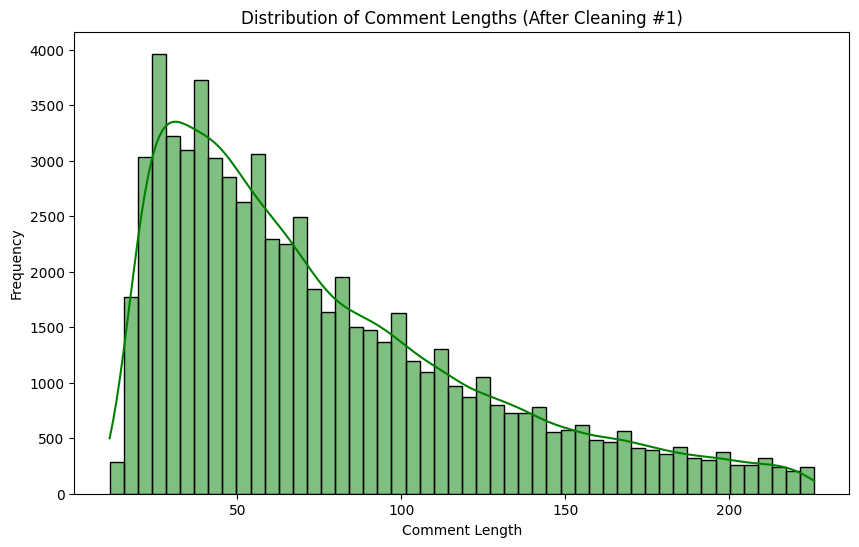

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #1)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [17]:
# حذف ردیف‌هایی که داده‌های خالی دارند
cleaned_df = cleaned_df.dropna()

# حذف ستون‌هایی که داده‌های خالی زیادی دارند
cleaned_df = cleaned_df.dropna(axis=1)

In [18]:
# شمارش داده‌های تکراری
print(f"تعداد داده‌های تکراری: {cleaned_df.duplicated().sum()}")

# حذف داده‌های تکراری
cleaned_df = cleaned_df.drop_duplicates()

تعداد داده‌های تکراری: 51


## Number of duplicate data's removed: 51

In [19]:
import re

def clean_comment(comment):
    comment = re.sub(r'\s+', ' ', comment)  # حذف فاصله‌های اضافی
    comment = re.sub(r'http\S+', '', comment)  # حذف لینک‌ها
    comment = re.sub(r'[^\w\s]', '', comment)  # حذف کاراکترهای خاص
    comment = re.sub(r'\d+', '', comment)  # حذف اعداد
    return comment.strip()

cleaned_df['comment_cleaned'] = cleaned_df['comment'].apply(clean_comment)

In [20]:
output_path = '/kaggle/working/cleaned_data.csv'  # مسیر ذخیره‌سازی فایل
cleaned_df.to_csv(output_path, index=False, encoding='utf-8')

In [21]:
print(cleaned_df.head())
print(cleaned_df.columns)

                                             comment  label  comment_length  \
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح      0              47   
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...      1             132   
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...      0              89   
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...      1              99   
4                      شیرینی وانیلی فقط یک مدل بود.      1              29   

                                     comment_cleaned  
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح  
1  قرار بود  ساعته برسه ولی نیم ساعت زودتر از موق...  
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...  
3  عالی بود همه چه درست و به اندازه و کیفیت خوب ا...  
4                       شیرینی وانیلی فقط یک مدل بود  
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='object')


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


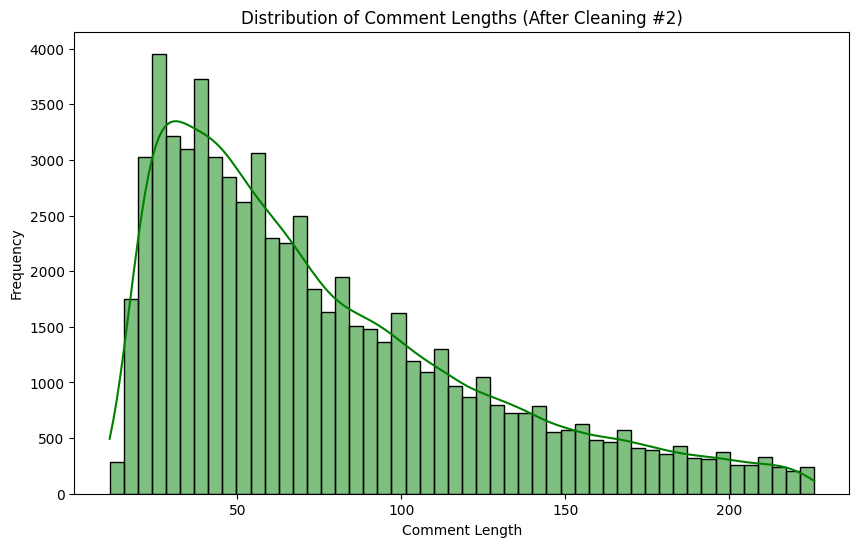

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [23]:
print(cleaned_df['label'].value_counts())

label
1    33675
0    32298
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

In [25]:
# خواندن دیتاست تمیز شده
cleaned_df = pd.read_csv("cleaned_data.csv")  # فرض بر این است که دیتاست تمیز شده در فایل موجود است

# تقسیم داده‌ها به سه مجموعه (آموزش 50%، اعتبارسنجی 20%، تست 30%)
train_data, temp_data = train_test_split(cleaned_df, test_size=0.5, stratify=cleaned_df['label'], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.6, stratify=temp_data['label'], random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# ذخیره داده‌ها برای استفاده‌های بعدی
train_data.to_csv("snappfood_train.csv", index=False)
val_data.to_csv("snappfood_val.csv", index=False)
test_data.to_csv("snappfood_test.csv", index=False)

print("دیتاست آماده شد و ذخیره گردید.")

# لود کردن توکنایزر
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased")  # تغییر دهید بر اساس مدل خودتان

# توکنایز کردن داده‌ها
train_encodings = tokenizer(list(train_data['comment']), truncation=True, padding=True, max_length=198)
val_encodings = tokenizer(list(val_data['comment']), truncation=True, padding=True, max_length=198)
test_encodings = tokenizer(list(test_data['comment']), truncation=True, padding=True, max_length=198)

# تبدیل برچسب‌ها به لیست
train_labels = list(train_data['label'])
val_labels = list(val_data['label'])
test_labels = list(test_data['label'])

print("توکنایز کردن داده‌ها با موفقیت انجام شد.")


Training samples: 32986
Validation samples: 13194
Test samples: 19793
دیتاست آماده شد و ذخیره گردید.


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


توکنایز کردن داده‌ها با موفقیت انجام شد.


In [26]:
# بارگذاری داده‌های تقسیم‌شده
train_data = pd.read_csv("snappfood_train.csv")
val_data = pd.read_csv("snappfood_val.csv")
test_data = pd.read_csv("snappfood_test.csv")

In [27]:
# ذخیره داده‌های تقسیم‌شده
train_data.to_csv("snappfood_train.csv", index=False)
val_data.to_csv("snappfood_val.csv", index=False)
test_data.to_csv("snappfood_test.csv", index=False)

print("داده‌ها با موفقیت ذخیره شدند.")

داده‌ها با موفقیت ذخیره شدند.


In [28]:
!pip install transformers

In [29]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd

In [30]:
# بارگذاری مدل و توکنایزر ParsBERT
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# تعریف کلاس دیتاست برای PyTorch
class snappfoodDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        # توکنایز کردن متن
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/621 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/651M [00:00<?, ?B/s]

In [31]:
# تعریف دیتاست‌ها
train_dataset = snappfoodDataset(
    texts=train_data["comment"].tolist(),
    labels=train_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)

val_dataset = snappfoodDataset(
    texts=val_data["comment"].tolist(),
    labels=val_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)

test_dataset = snappfoodDataset(
    texts=test_data["comment"].tolist(),
    labels=test_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)

In [32]:
batch_size = 16

# تعریف DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("مدل و داده‌ها آماده شدند.")

مدل و داده‌ها آماده شدند.


In [33]:
# انتقال مدل به GPU در صورت وجود
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [34]:
import torch
import time
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import torch.nn as nn

In [35]:
pip install torchsummary


Note: you may need to restart the kernel to use updated packages.


In [36]:
# بارگذاری مدل از Hugging Face
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

In [37]:
# افزودن Dropout و L2 Regularization
class CustomParsBERT(nn.Module):
    def __init__(self, model, dropout_prob=0.3, l2_lambda=0.01):
        super(CustomParsBERT, self).__init__()
        self.bert = model.bert
        self.dropout = nn.Dropout(p=dropout_prob)
        self.classifier = nn.Linear(model.config.hidden_size, model.config.num_labels)
        self.l2_lambda = l2_lambda

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            # افزودن L2 Regularization
            l2_reg = sum(param.norm(2) for param in self.classifier.parameters())
            loss += self.l2_lambda * l2_reg

            return loss, logits
        return logits

In [38]:
# تابع آموزش مدل
def train_model(learning_rate, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CustomParsBERT(base_model)  # استفاده از base_model به جای base_model نامعتبر
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_epochs = 10

    for epoch in range(num_epochs):
        torch.cuda.empty_cache()
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}, LR={learning_rate}, BS={batch_size}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            loss, logits = model(input_ids, attention_mask, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        # ارزیابی مدل روی داده اعتبارسنجی
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                loss, logits = model(input_ids, attention_mask, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(val_labels, val_preds)
        print(f"Epoch {epoch + 1}: Validation Accuracy: {val_accuracy:.4f}")

    return model, val_accuracy
    

# تنظیم هایپرپارامترها
learning_rates = [1e-6]
batch_sizes = [8]


best_accuracy = 0
best_model = None
best_params = {}

for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"Training with lr={lr}, batch_size={batch_size}")
        model, val_accuracy = train_model(lr, batch_size)

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model = model
            best_params = {'learning_rate': lr, 'batch_size': batch_size}

print(f"Best Accuracy: {best_accuracy}")
print(f"Best Params: {best_params}")

# ذخیره مدل بهترین مدل
torch.save(best_model.state_dict(), 'best_model.pth')
print("Best model saved as 'best_model.pth'")

Training with lr=1e-06, batch_size=8


Epoch 1/10, LR=1e-06, BS=8: 100%|██████████| 2062/2062 [12:45<00:00,  2.70it/s]


Epoch 1: Validation Accuracy: 0.9289


Epoch 2/10, LR=1e-06, BS=8: 100%|██████████| 2062/2062 [12:46<00:00,  2.69it/s]


Epoch 2: Validation Accuracy: 0.9295


...

Epoch 8: Validation Accuracy: 0.9283


Epoch 9/10, LR=1e-06, BS=8: 100%|██████████| 2062/2062 [12:46<00:00,  2.69it/s]


Epoch 9: Validation Accuracy: 0.9277


Epoch 10/10, LR=1e-06, BS=8: 100%|██████████| 2062/2062 [12:46<00:00,  2.69it/s]


Epoch 10: Validation Accuracy: 0.9267
Best Accuracy: 0.9267091102016068
Best Params: {'learning_rate': 1e-06, 'batch_size': 8}
Best model saved as 'best_model.pth'


In [46]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

<ipython-input-46-1a0b334b2e30>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


CustomParsBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [40]:
# فرض کنید که شما از دیتاست خود بچ گرفته‌اید، اینجا یک مثال برای آن آورده شده است:
batch = next(iter(train_loader))  # این به طور موقت از train_loader استفاده می‌کند
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)

# استفاده از مدل برای پیش‌بینی
logits = model(input_ids, attention_mask, labels=None)
preds = torch.argmax(logits, dim=1).cpu().numpy()

In [41]:
from sklearn.metrics import classification_report

In [42]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating Model"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # دریافت logits از مدل
            outputs = model(input_ids, attention_mask)
            logits = model(input_ids, attention_mask)

            # محاسبه پیش‌بینی‌ها
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه معیارهای عملکرد
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # نمایش نتایج
    print("Test Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("\\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

# بارگذاری مدل ذخیره‌شده
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# ارزیابی مدل
evaluate_model(model, test_loader, device)


<ipython-input-42-719112a4d86d>:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
Evaluating Model: 100%|██████████| 1238

Test Results:
  Accuracy: 0.9259
  Precision: 0.9268
  Recall: 0.9259
  F1-Score: 0.9259
\nClassification Report:
              precision    recall  f1-score   support

           0     0.9059    0.9471    0.9260      9690
           1     0.9469    0.9057    0.9258     10103

    accuracy                         0.9259     19793
   macro avg     0.9264    0.9264    0.9259     19793
weighted avg     0.9268    0.9259    0.9259     19793



Plotting ROC curve...


100%|██████████| 1238/1238 [02:13<00:00,  9.26it/s]


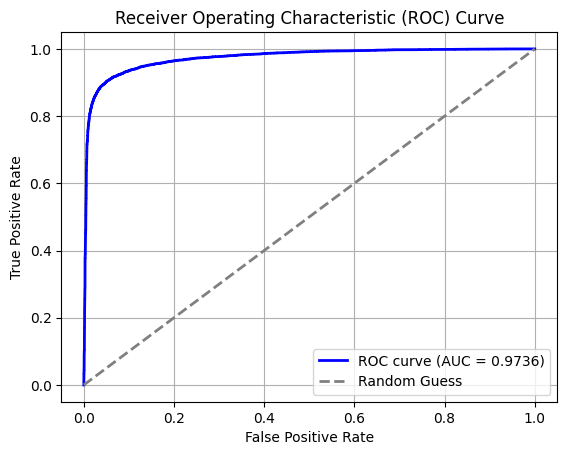

In [43]:
from sklearn.metrics import roc_curve, auc

# تابع ارزیابی برای محاسبه ROC
def evaluate_roc_curve(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, labels=None)  # فقط logits دریافت می‌شود
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # احتمال کلاس مثبت
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه FPR، TPR و AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # رسم منحنی ROC
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# ارزیابی مدل و رسم منحنی ROC
print("Plotting ROC curve...")
evaluate_roc_curve(model, test_loader, device)


In [44]:
# فرض بر این است که 'val_dataset' شامل داده‌های متنی است که به صورت لیست ذخیره شده‌اند
val_texts = val_dataset.texts  # یا روش مناسب دیگر برای دسترسی به داده‌های متنی
val_labels = val_dataset.labels  # یا روش مناسب دیگر برای دسترسی به برچسب‌ها

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    # دریافت logits از مدل
    logits = best_model(input_ids, attention_mask)

    # محاسبه پیش‌بینی‌ها
    val_predictions = logits.argmax(axis=1)

    # استخراج خطاها
    errors = [text for text, pred, label in zip(val_texts, val_predictions, val_labels) if pred != label]
    print("\nErrors:")
    print(errors)


Errors:
[]

Errors:
['بنری و پیتزای که سفارش داده بودیم بندریش که فقط فقط سوسی داش پتیزاش خیلی بد مزه و ب یکیفت بود', 'بسیار عالی-باتشکر از دومینوز و اسنپ فود', 'خیلی عالی، سریع، تمیز، طعم عالی، بسته بندی عالی تعجب کردم که با این مبلغ برای دیزی همه مخلفات هم همراهش بود پیشنهاد می\u200cکنم بدون شک یکبار امتحان کنید', 'بادوم زمینی\u200cکه سفارش دادم ۴ هزار تومن قیمت داشت و ۷۰ گرمی چیزی که فرستادید ۲ هزار تومنی بود و وزن نصف، برام عجیبه چرا هیچ وقت برعکش اتفاق نمی\u200cافته لطفا دقت کنید در\u200cارسال', 'افتضاح مقداری پنیر پیتزا و خمیر نون که خوب بود با قاشق بخوری اصلا نمی\u200cشد یه تکه پیتزا برداشت هروقت تو این محدوده پیتزا سفارش دادم پشیمون شدم هیچ کدوم کیفیت ندارن', 'آقا لطفا روی سیب\u200cزمینی سس نریز، انقد ریخته بودی از تو ظرف ریخته بود بیرون کل کیسه سسی شده بود، اگه علاقه به سس داری تو یه ظرف جدا بریز', 'من راضی اسلامی راضی دیگه چی بخوام']

Errors:
['من نوشابه شیشه\u200cای اسپرایت سفارش دادم که قیمتش هم بالاتره ولی نوشابه بطری\u200cای پلاستیکی فرستادن، یعنی پولش رو گرفته سوپرمارکت

In [45]:
# دیکشنری برای ذخیره‌سازی تعداد پیش‌بینی‌های اشتباه بر اساس کلاس‌ها
incorrect_predictions_by_class = {}

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    # دریافت logits از مدل
    logits = best_model(input_ids, attention_mask)

    # محاسبه پیش‌بینی‌ها
    val_predictions = logits.argmax(axis=1)

    # شمارش پیش‌بینی‌های اشتباه و گروه‌بندی بر اساس کلاس‌ها
    for pred, label in zip(val_predictions, val_labels):
        if pred != label:
            if label not in incorrect_predictions_by_class:
                incorrect_predictions_by_class[label] = 0
            incorrect_predictions_by_class[label] += 1  # افزایش شمارش پیش‌بینی‌های اشتباه برای هر کلاس

# چاپ تعداد پیش‌بینی‌های اشتباه بر اساس کلاس‌ها
for class_label, error_count in incorrect_predictions_by_class.items():
    print(f"Class {class_label} - Misclassified samples count: {error_count}")

Class 0 - Misclassified samples count: 2878
Class 1 - Misclassified samples count: 3800


### The number of misclassified data's from both classes is 6678.